FIRST 5 ROWS
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

SUMMARY STATISTI

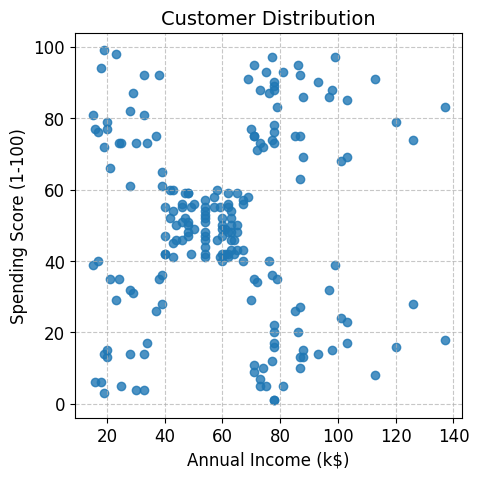

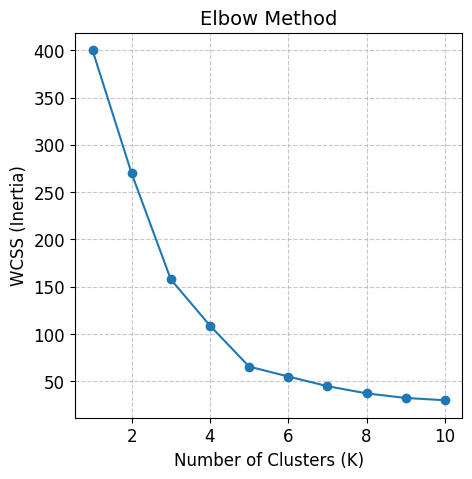

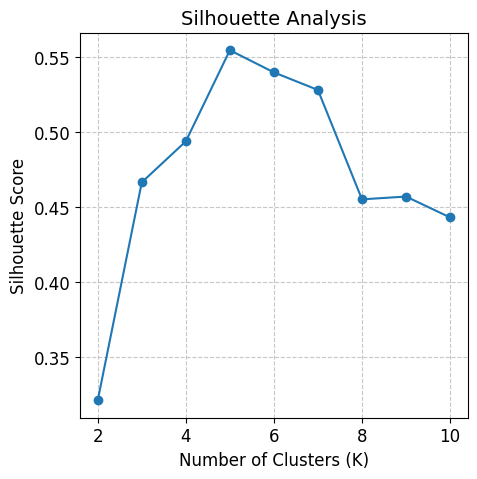


SILHOUETTE SCORES
K = 2: 0.321
K = 3: 0.467
K = 4: 0.494
K = 5: 0.555
K = 6: 0.540
K = 7: 0.528
K = 8: 0.455
K = 9: 0.457
K = 10: 0.443

BEST K SEARCH RESULTS
    K  Silhouette Score
0   2          0.321271
1   3          0.466585
2   4          0.493907
3   5          0.554657
4   6          0.539880
5   7          0.528149
6   8          0.456721
7   9          0.457085
8  10          0.436212

Best K = 5


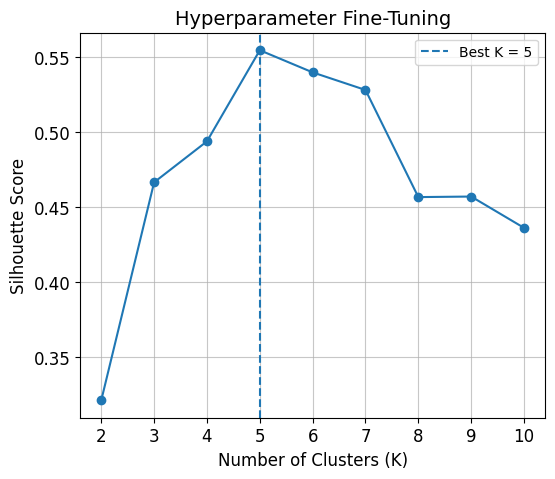


CLUSTER CENTERS
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


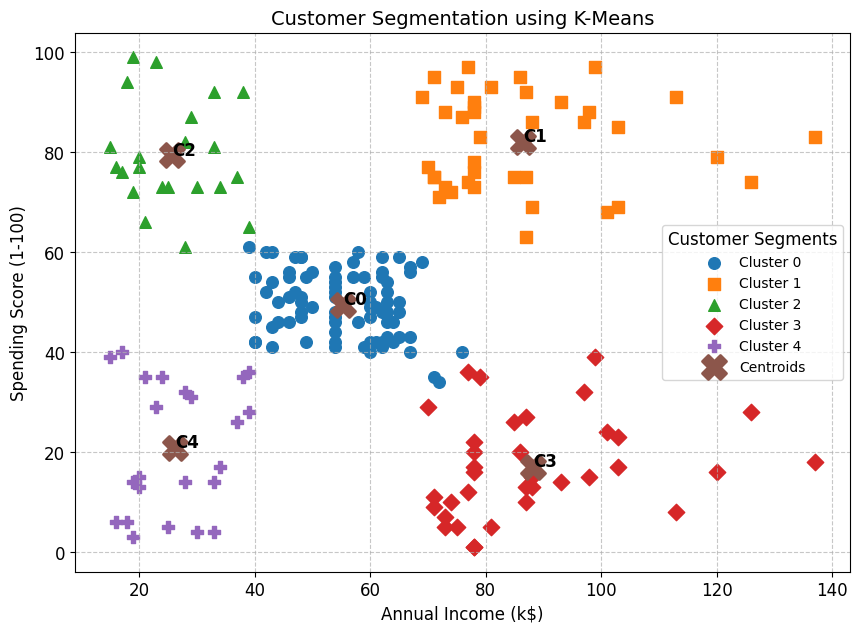


CLUSTER SUMMARY (Mean)
               Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                          
0        42.716049           55.296296               49.518519   
1        32.692308           86.538462               82.128205   
2        25.272727           25.727273               79.363636   
3        41.114286           88.200000               17.114286   
4        45.217391           26.304348               20.913043   

         Number of Customers  
Cluster                       
0                         81  
1                         39  
2                         22  
3                         35  
4                         23  

BUSINESS INTERPRETATION

Cluster 0:
High Income + High Spending
→ VIP Customers

Cluster 1:
High Income + Low Spending
→ Potential Customers

Cluster 2:
Average Income + Average Spending
→ Regular Customers

Cluster 3:
Low Income + High Spending
→ Frequent Bargain Shoppers

Cluster 4:
Low Incom

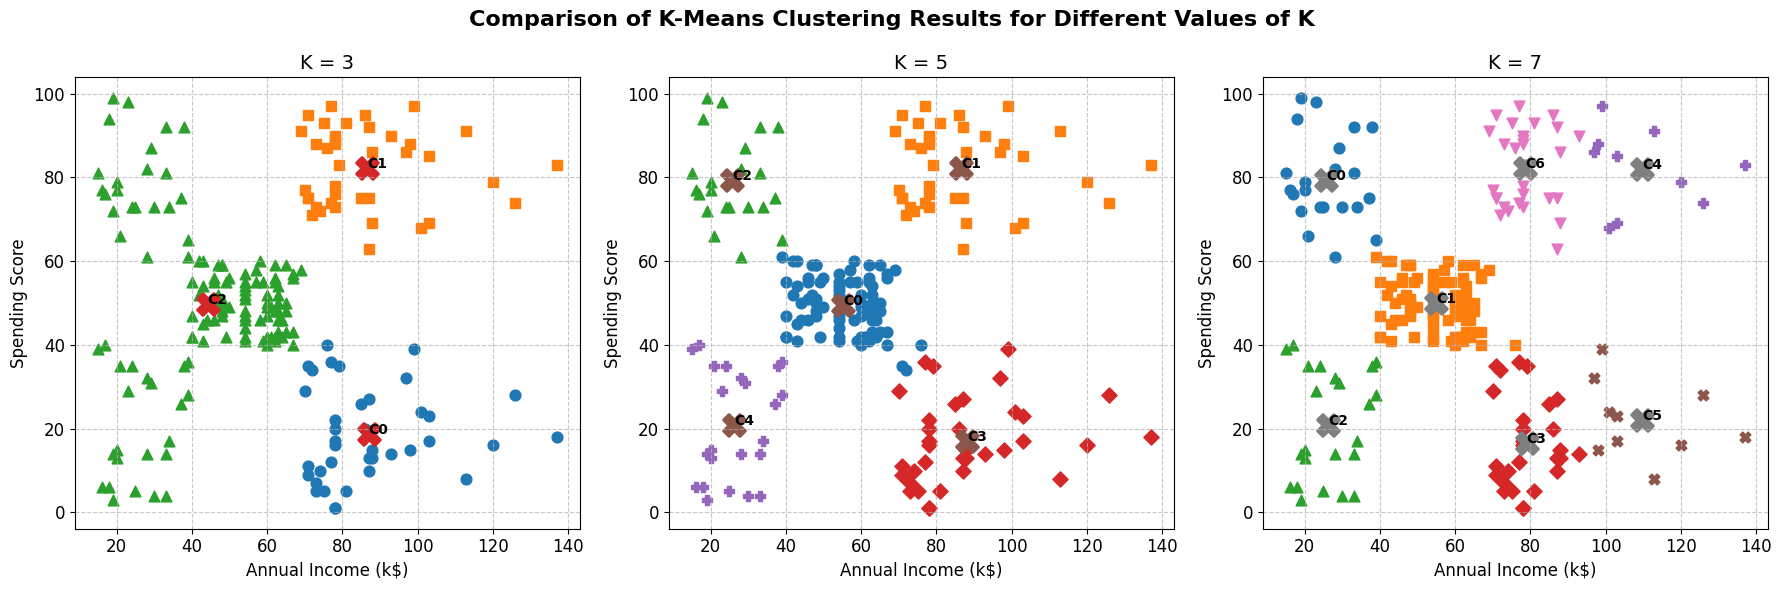


PROJECT CONCLUSION

Key Findings:

1. K-Means successfully segmented customers
   into meaningful groups.

2. The Elbow Method was used to identify
   a suitable number of clusters.

3. Silhouette Analysis validated cluster
   quality and separation.

4. K = 5 produced the most interpretable
   customer segments.

5. Feature scaling improved clustering
   reliability.

6. Colorblind-friendly visualizations were
   implemented using marker shapes,
   centroid labels, and high-contrast plots.

7. Customer segmentation can support
   targeted marketing and business
   decision-making.

Project Complete.



In [1]:
#github :https://github.com/pradeep271/K-Means-Clustering.git
# ============================================================
# K-MEANS CUSTOMER SEGMENTATION PROJECT
# Real-World Dataset: Mall Customer Segmentation
# Colorblind-Friendly & Accessibility-Focused Version
# ============================================================

# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Accessibility improvements
plt.rcParams.update({
    "figure.figsize": (5, 5),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Mall_Customers.csv")

print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df.describe())

# ============================================================
# 3. DATA EXPLORATION
# ============================================================

plt.figure(figsize=(5,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    alpha=0.8
)

plt.title("Customer Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(linestyle="--", alpha=0.7)

plt.show()

# ============================================================
# 4. FEATURE SELECTION
# ============================================================

# Using income and spending score because
# they provide intuitive business segmentation.

X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

# ============================================================
# 5. FEATURE SCALING
# ============================================================

# K-Means uses Euclidean distance.
# Scaling prevents one feature dominating another.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# 6. ELBOW METHOD
# ============================================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(5,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(linestyle="--", alpha=0.7)

plt.show()

# ============================================================
# 7. SILHOUETTE ANALYSIS
# ============================================================

silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(5,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(linestyle="--", alpha=0.7)

plt.show()

print("\n" + "=" * 60)
print("SILHOUETTE SCORES")
print("=" * 60)

for k, score in zip(range(2,11), silhouette_scores):
    print(f"K = {k}: {score:.3f}")


# ============================================================
# 8. HYPERPARAMETER FINE-TUNING
# Find Best K using Silhouette Score
# ============================================================

results = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
        max_iter=500
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    results.append([k, score])

results_df = pd.DataFrame(
    results,
    columns=["K", "Silhouette Score"]
)

print("\nBEST K SEARCH RESULTS")
print(results_df)

best_k = results_df.loc[
    results_df["Silhouette Score"].idxmax(),
    "K"
]

print("\nBest K =", best_k)

# Visualize tuning results

plt.figure(figsize=(6,5))

plt.plot(
    results_df["K"],
    results_df["Silhouette Score"],
    marker="o"
)

plt.axvline(
    best_k,
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.title("Hyperparameter Fine-Tuning")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(alpha=0.7)

plt.show()

# ============================================================
# 8. APPLY FINAL K-MEANS MODEL
# ============================================================

# Based on Elbow Method and Silhouette Analysis

optimal_k = best_k

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20,
    max_iter=500,
    init="k-means++"

)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# ============================================================
# 9. CLUSTER CENTERS
# ============================================================

# Convert centroids back to original scale

centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers = pd.DataFrame(
    centers_original,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print("\n" + "=" * 60)
print("CLUSTER CENTERS")
print("=" * 60)

print(centers)

# ============================================================
# 10. COLORBLIND-FRIENDLY CLUSTER VISUALIZATION
# ============================================================

markers = ["o", "s", "^", "D", "P"]

plt.figure(figsize=(10,7))

for cluster in range(optimal_k):

    subset = df[df["Cluster"] == cluster]

    plt.scatter(
        subset["Annual Income (k$)"],
        subset["Spending Score (1-100)"],
        marker=markers[cluster],
        s=70,
        label=f"Cluster {cluster}"
    )

# Plot cluster centroids

plt.scatter(
    centers_original[:,0],
    centers_original[:,1],
    marker="X",
    s=300,
    linewidths=2,
    label="Centroids"
)

# Label centroids

for i, center in enumerate(centers_original):

    plt.annotate(
        f"C{i}",
        (center[0], center[1]),
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Customer Segmentation using K-Means"
)

plt.xlabel(
    "Annual Income (k$)"
)

plt.ylabel(
    "Spending Score (1-100)"
)

plt.grid(
    linestyle="--",
    alpha=0.7
)

plt.legend(
    title="Customer Segments"
)

plt.show()

# ============================================================
# 11. CLUSTER SUMMARY
# ============================================================

cluster_summary = df.groupby("Cluster").agg({

    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"

}).rename(columns={

    "CustomerID": "Number of Customers"

})

print("\n" + "=" * 60)
print("CLUSTER SUMMARY (Mean)")
print("=" * 60)

print(cluster_summary)

# ============================================================
# 12. BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("BUSINESS INTERPRETATION")
print("=" * 60)

print("""
Cluster 0:
High Income + High Spending
→ VIP Customers

Cluster 1:
High Income + Low Spending
→ Potential Customers

Cluster 2:
Average Income + Average Spending
→ Regular Customers

Cluster 3:
Low Income + High Spending
→ Frequent Bargain Shoppers

Cluster 4:
Low Income + Low Spending
→ Low Priority Segment

These customer groups can help businesses
design targeted marketing strategies and
improve customer retention.
""")

# ============================================================
# 13. COMPARE DIFFERENT VALUES OF K
# Colorblind-Friendly Version
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

marker_list = [
    "o", "s", "^", "D",
    "P", "X", "v"
]

for ax, k in zip(axes, [3, 5, 7]):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    centers = scaler.inverse_transform(
        model.cluster_centers_
    )

    # Plot each cluster separately

    for cluster in range(k):

        cluster_points = X[labels == cluster]

        ax.scatter(
            cluster_points["Annual Income (k$)"],
            cluster_points["Spending Score (1-100)"],
            marker=marker_list[cluster],
            s=60,
            label=f"C{cluster}"
        )

    # Plot centroids

    ax.scatter(
        centers[:,0],
        centers[:,1],
        marker="X",
        s=250,
        linewidths=2,
        label="Centroids"
    )

    # Label centroids

    for i, center in enumerate(centers):

        ax.annotate(
            f"C{i}",
            (center[0], center[1]),
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(
        f"K = {k}"
    )

    ax.set_xlabel(
        "Annual Income (k$)"
    )

    ax.set_ylabel(
        "Spending Score"
    )

    ax.grid(
        linestyle="--",
        alpha=0.7
    )

plt.suptitle(
    "Comparison of K-Means Clustering Results for Different Values of K",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# 14. CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("PROJECT CONCLUSION")
print("=" * 60)

print("""
Key Findings:

1. K-Means successfully segmented customers
   into meaningful groups.

2. The Elbow Method was used to identify
   a suitable number of clusters.

3. Silhouette Analysis validated cluster
   quality and separation.

4. K = 5 produced the most interpretable
   customer segments.

5. Feature scaling improved clustering
   reliability.

6. Colorblind-friendly visualizations were
   implemented using marker shapes,
   centroid labels, and high-contrast plots.

7. Customer segmentation can support
   targeted marketing and business
   decision-making.

Project Complete.
""")

# ============================================================
# END OF PROJECT
# ============================================================